In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
gdf = gpd.read_file('data/processed/Collision_Processed.geojson')
gdf

,COLDETKEY,LOCATION,SEVERITYCODE,SEVERITYDESC,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,INJURIES,SERIOUSINJURIES,...,HOUR,Day_of_Week,Season,X,Y,SEVERITY,TOTAL_PED,lat_bin,lon_bin,geometry
0,321500,41ST AVE SW BETWEEN SW ALASKA ST AND SW EDMUND...,0,Unknown,0,0,0,0,0,0,...,NaN,Friday,Spring,-122.384178,47.560196,0,0,"(47.559, 47.561]","(-122.384, -122.383]",POINT (-122.38418 47.5602)
1,371480,15TH AVE W BETWEEN MAGNOLIA BR AND W BLAINE ST,2,Injury Collision,5,0,0,2,1,0,...,17.0,Thursday,Fall,-122.376154,47.634164,1,0,"(47.634, 47.636]","(-122.377, -122.376]",POINT (-122.37615 47.63416)
2,197820,E OLIVE WAY BETWEEN MELROSE AVE AND BELLEVUE AVE,2,Injury Collision,2,0,0,2,1,0,...,2.0,Saturday,Summer,-122.327370,47.616867,1,0,"(47.617, 47.618]","(-122.328, -122.327]",POINT (-122.32737 47.61687)
3,246100,20TH AVE NE AND NE 145TH ST,2,Injury Collision,4,0,0,2,1,0,...,10.0,Friday,Summer,-122.307359,47.733896,1,0,"(47.733, 47.734]","(-122.309, -122.307]",POINT (-122.30736 47.7339)
4,332400,36TH AVE SW AND SW AVALON WAY,1,Property Damage Only Collision,3,0,0,2,0,0,...,11.0,Thursday,Spring,-122.377464,47.564083,0,0,"(47.563, 47.564]","(-122.378, -122.377]",POINT (-122.37746 47.56408)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103560,390077,GREENWOOD AVE N BETWEEN RIDGEMONT WAY N AND N ...,1,Property Damage Only Collision,2,0,0,2,0,0,...,14.0,Wednesday,Winter,-122.355553,47.719395,0,0,"(47.718, 47.72]","(-122.356, -122.354]",POINT (-122.35555 47.71939)
103561,387698,8TH AVE NW BETWEEN NW 77TH N ST AND NW 78TH ST,2,Injury Collision,2,0,1,1,1,0,...,18.0,Friday,Summer,-122.366020,47.685287,1,1,"(47.685, 47.686]","(-122.367, -122.366]",POINT (-122.36602 47.68529)
103562,387322,AURORA AVE N BETWEEN N 87TH ST AND N 88TH S ST,2b,Serious Injury Collision,1,0,0,1,1,1,...,2.0,Saturday,Fall,-122.344556,47.692202,4,0,"(47.691, 47.693]","(-122.346, -122.345]",POINT (-122.34456 47.6922)
103563,387419,AIRPORT WAY S BETWEEN S NORFOLK ST AND CITY LI...,2,Injury Collision,2,0,0,0,1,0,...,NaN,Friday,Summer,-122.287118,47.511862,1,0,"(47.512, 47.513]","(-122.287, -122.286]",POINT (-122.28712 47.51186)


In [3]:
grid = gdf.groupby(['lat_bin', 'lon_bin']).agg(
    collision_count=('COLDETKEY','count'),
    mean_severity=('SEVERITY', 'mean'),
    total_injuries=('INJURIES', 'sum'),
    total_serious=('SERIOUSINJURIES', 'sum'),
    total_fatalities=('FATALITIES','sum'),
    avg_vehicle_count=('VEHCOUNT', 'mean'),
    avg_pedestrian_count=('TOTAL_PED', 'mean')
).reset_index()


## Predictor
The predictor variable, `risk_label`, is derived from the `collision_count` and `mean_severity` features. After normalizing, the most optimal weights are applied (0.6, 0.4) to create `risk_score` and `risk_label`.

In [4]:
scaler = StandardScaler()
grid[['c_density_norm', 's_severity_norm']] = scaler.fit_transform(grid[['collision_count', 'mean_severity']])
grid['risk_score'] = 0.6 * grid['c_density_norm'] + 0.4 * grid['s_severity_norm']
grid['risk_label'] = pd.qcut(grid['risk_score'], q=3, labels=['1 Low Risk', '2 Medium Risk', '3 High Risk'])
grid.get(['risk_score', 'risk_label'])

,risk_score,risk_label
0,-0.051852,2 Medium Risk
1,0.008514,2 Medium Risk
2,0.008278,2 Medium Risk
3,-0.629087,1 Low Risk
4,-0.659482,1 Low Risk
...,...,...
8353,0.615247,3 High Risk
8354,0.911644,3 High Risk
8355,-0.173718,2 Medium Risk
8356,1.161424,3 High Risk


## Risk Classification
**Features:**
- `cell_lat`, `cell_lon` — spatial position
- `peak_hour`, `night_ratio`, `weekend_ratio`, `winter_ratio`, `summer_ratio` — when collisions cluster
- `ped_involvement_ratio`, `cyclist_involvement_ratio` — who is involved (collision mix)
- `intersection_ratio` — intersection vs mid-block character (parsed from `LOCATION`)

In [ ]:
le = LabelEncoder()

# Engineer context features
zone_ctx = gdf.groupby(['lat_bin', 'lon_bin'], observed=True).agg(
    cell_lat=('Y', 'mean'),
    cell_lon=('X', 'mean'),
    peak_hour=('HOUR', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    night_ratio=('HOUR', lambda x: ((x < 6) | (x >= 20)).mean()),
    weekend_ratio=('Day_of_Week', lambda x: x.isin(['Saturday', 'Sunday']).mean()),
    winter_ratio=('Season', lambda x: (x == 'Winter').mean()),
    summer_ratio=('Season', lambda x: (x == 'Summer').mean()),
    ped_involvement_ratio=('PEDCOUNT', lambda x: (x > 0).mean()),
    cyclist_involvement_ratio=('PEDCYLCOUNT', lambda x: (x > 0).mean()),
    intersection_ratio=('LOCATION', lambda x: x.str.contains(' AND ', na=False).mean()),
).reset_index()

grid_ctx = grid.merge(zone_ctx, on=['lat_bin', 'lon_bin'], how='left')
grid_ctx['peak_hour'] = grid_ctx['peak_hour'].fillna(grid_ctx['peak_hour'].median())

features = ['cell_lat', 'cell_lon', 'peak_hour', 'night_ratio',
                        'weekend_ratio', 'winter_ratio', 'summer_ratio',
                        'ped_involvement_ratio', 'cyclist_involvement_ratio',
                        'intersection_ratio']

X = grid_ctx[features]
y = le.fit_transform(grid_ctx['risk_label'])
grid_ctx[features].describe()

,cell_lat,cell_lon,peak_hour,night_ratio,weekend_ratio,winter_ratio,summer_ratio,ped_involvement_ratio,cyclist_involvement_ratio,intersection_ratio
count,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.0
mean,47.621297,-122.332552,10.982053,0.194773,0.259954,0.243141,0.255746,0.028224,0.027013,1.0
std,0.063640,0.038335,5.581377,0.244714,0.264911,0.255510,0.256282,0.089757,0.096444,0.0
min,47.496390,-122.425297,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,47.563900,-122.362951,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,47.626991,-122.330093,11.000000,0.137931,0.222222,0.210526,0.230769,0.000000,0.000000,1.0
75%,47.675789,-122.301909,15.000000,0.285714,0.363636,0.333333,0.333333,0.000000,0.000000,1.0
max,47.734143,-122.238964,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0


CV accuracy: [0.686 0.681 0.68  0.678 0.694]
Mean CV accuracy: 0.684

Test accuracy: 0.666

Classification report:
                precision    recall  f1-score   support

   1 Low Risk       0.72      0.77      0.74       580
2 Medium Risk       0.54      0.72      0.61       537
  3 High Risk       0.84      0.51      0.63       555

     accuracy                           0.67      1672
    macro avg       0.70      0.66      0.66      1672
 weighted avg       0.70      0.67      0.67      1672



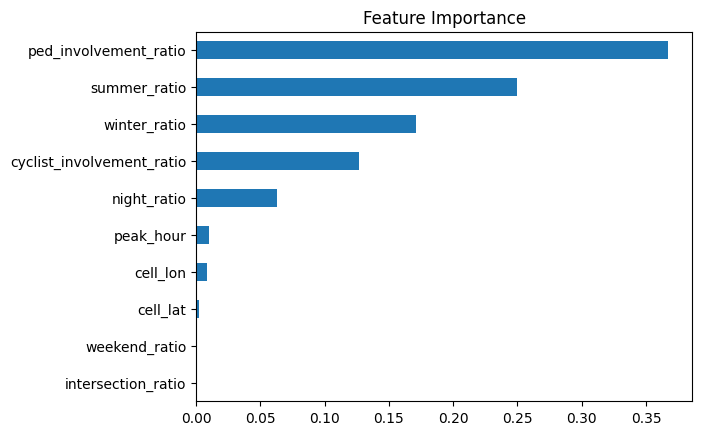

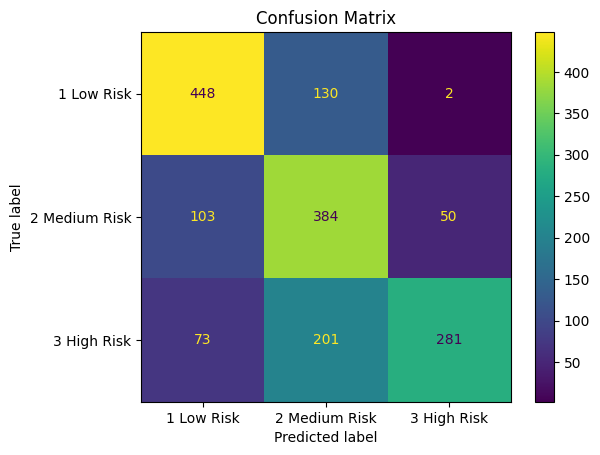

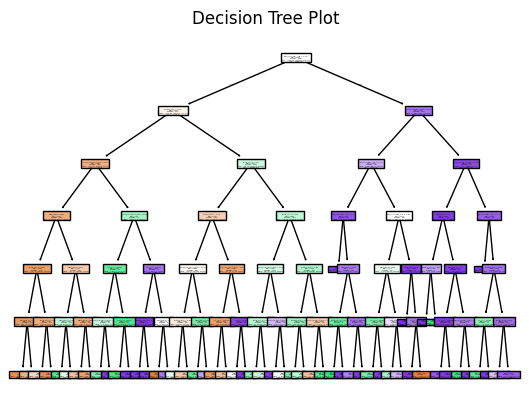

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
model = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv)

print('CV accuracy:', np.round(cv_scores, 3))
print('Mean CV accuracy:', np.round(cv_scores.mean(), 3))

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('\nTest accuracy:', np.round(accuracy_score(y_test, y_pred), 3))
print('\nClassification report:\n', classification_report(y_test, y_pred, target_names=le.classes_))

fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
fi.plot(kind='barh')
plt.title('Feature Importance')
plt.show()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()
plt.title('Confusion Matrix')
plt.show()

plot_tree(model, feature_names=features, class_names=le.classes_, filled=True)
plt.title('Decision Tree Plot')
plt.show()

In [7]:
# Extract lat/lon from bins for mapping
def parse_interval(s):
    s = s.strip('()[]')
    left, right = s.split(', ')
    return (float(left) + float(right)) / 2

grid['lat'] = grid['lat_bin'].apply(parse_interval)
grid['lon'] = grid['lon_bin'].apply(parse_interval)

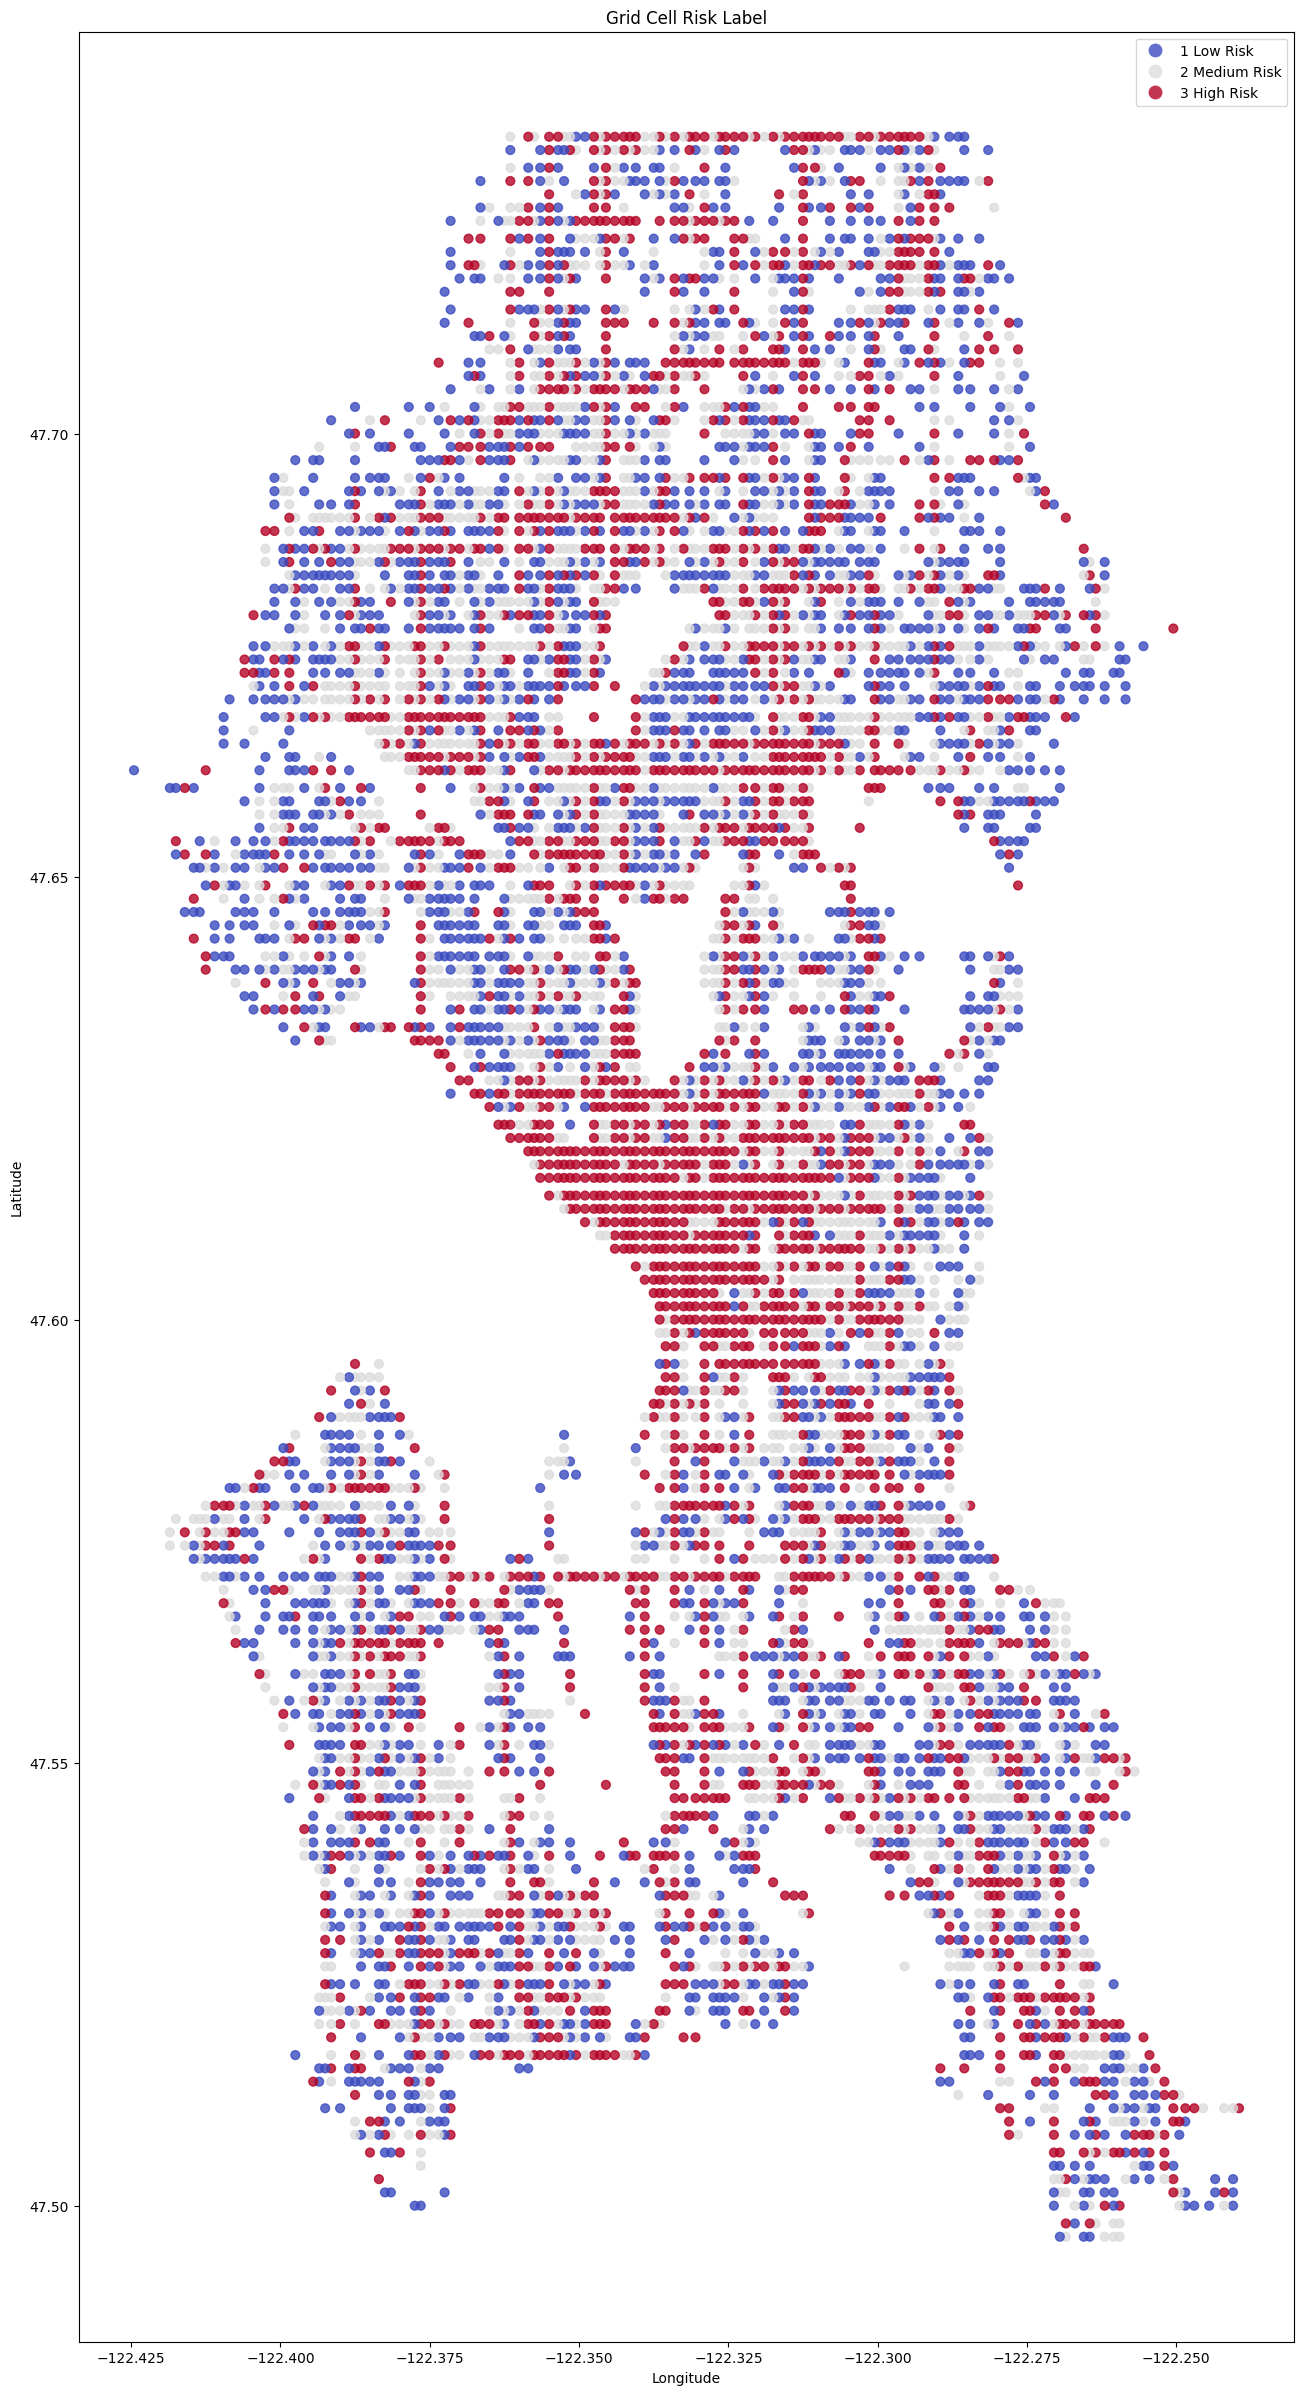

In [8]:
risk_map = gpd.GeoDataFrame(grid, geometry=gpd.points_from_xy(grid.lon, grid.lat), crs=gdf.crs)

fig, ax = plt.subplots(1,1,figsize=(36,30))
risk_map.plot(column='risk_label', categorical=True, legend=True,
              cmap='coolwarm', ax=ax, markersize=40, alpha=0.8)
ax.set_title('Grid Cell Risk Label')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()